#**Task 01**

## **you will build a sales or demand forecasting system using historical business data.**

# **Business Context**

Sales forecasting is one of the most widely used Machine Learning applications in real businesses. Companies rely on forecasts to:

* plan inventory
* manage cash flow
* prepare staffing
* avoid overstocking or losses

This task helps you understand how Machine Learning supports real business decisions, not just how to train a model.

# **Objective**

Your goal is to predict future sales or demand based on past data and present the results in a clear, business-friendly way.

    Instead of focusing only on accuracy, you will also learn:

        * How to prepare time-based data
        * How to explain trends and seasonality
        * How forecasts help business planning

# **Key Features to Implement**
Solution should include:

* Data cleaning and handling missing values

* Time-based feature engineering (dates, trends, seasonality)

* Forecasting using regression or time-series approaches

* Model evaluation and error analysis

* Business-friendly forecast visualizations

# **Tools used**

## **Core ML & Development Tools**
**Python** – https://www.python.org

## **ML & Data Libraries**
**Pandas** – https://pandas.pydata.org

**NumPy** – https://numpy.org

**Scikit-learn** – https://scikit-learn.org

## **Visualization Tools**
**Matplotlib** – https://matplotlib.org



# **Choosed Dataset**

## **Store Sales to perform Time Series Forecasting**

The Dataset is uploaded into Google drive


# **Downloading necessary packages**

In [ ]:
!pip install statsmodels

# **Importing Necessary Header Files**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import zipfile
import os
%matplotlib inline

# Time-series tools
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Models (regression-based)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Validation and preprocessing
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import r2_score as R2

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')

# **Importing dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset = '/content/drive/MyDrive/Artificial intelligence(AI) & Machine Learning(ML) /FUTURE INTERNS/TASK 01/Dataset/store-sales-time-series-forecasting.zip'
datasets = dataset

In [ ]:
with zipfile.ZipFile(datasets, 'r') as zip_ref:
    zip_ref.extractall('/content/store-sales-time-series-forecasting')

os.listdir('/content/store-sales-time-series-forecasting')

['sample_submission.csv',
 'train.csv',
 'stores.csv',
 'test.csv',
 'oil.csv',
 'holidays_events.csv',
 'transactions.csv']

# **Data cleaning and missing values**

since we have 7 datasets i going to perform Data Overview for each dataset

In [ ]:
train = pd.read_csv('/content/store-sales-time-series-forecasting/train.csv')
stores = pd.read_csv('/content/store-sales-time-series-forecasting/stores.csv')
oil = pd.read_csv('/content/store-sales-time-series-forecasting/oil.csv')
holidays = pd.read_csv('/content/store-sales-time-series-forecasting/holidays_events.csv')
transactions = pd.read_csv('/content/store-sales-time-series-forecasting/transactions.csv')

In [ ]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [ ]:
transactions.tail()

,date,store_nbr,transactions
83483,2017-08-15,50,2804
83484,2017-08-15,51,1573
83485,2017-08-15,52,2255
83486,2017-08-15,53,932
83487,2017-08-15,54,802


In [ ]:
transactions.isnull().sum()

,0
date,0
store_nbr,0
transactions,0


In [ ]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [ ]:
train.tail()

,id,date,store_nbr,family,sales,onpromotion
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0


In [ ]:
train.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [ ]:
holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [ ]:
holidays.tail()

,date,type,locale,locale_name,description,transferred
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False
349,2017-12-26,Additional,National,Ecuador,Navidad+1,False


In [ ]:
holidays.isnull().sum()

,0
date,0
type,0
locale,0
locale_name,0
description,0
transferred,0


In [ ]:
print(f"The shape of train dataset is {train.shape}")
print(f"The shape of transactions dataset is {transactions.shape}")
print(f"The shape of oil dataset is {oil.shape}")
print(f"The shape of holidays dataset is {holidays.shape}")
print(f"The shape of stores dataset is {stores.shape}")

The shape of train dataset is (3000888, 6)
The shape of transactions dataset is (83488, 3)
The shape of oil dataset is (1218, 2)
The shape of holidays dataset is (312, 6)
The shape of stores dataset is (54, 5)


In [ ]:
print(f"The duplicate values in train dataset is {train.duplicated().sum()}")
print(f"The duplicate values in transactions dataset is {transactions.duplicated().sum()}")
print(f"The duplicate values in oil dataset is {oil.duplicated().sum()}")
print(f"The duplicate values in holidays dataset is {holidays.duplicated().sum()}")
print(f"The duplicate values in stores dataset is {stores.duplicated().sum()}")

The duplicate values in train dataset is 0
The duplicate values in transactions dataset is 0
The duplicate values in oil dataset is 0
The duplicate values in holidays dataset is 0
The duplicate values in stores dataset is 0


In [ ]:
# 1. Make date the same type everywhere
for d in (train, oil, transactions, holidays):
    d["date"] = pd.to_datetime(d["date"])

# 2. Holidays: keep one row per date (some dates have several entries)
holidays = holidays.drop_duplicates(subset="date")

# 3. Rename holiday columns so "type" is clear
holidays = holidays.rename(columns={"type": "holiday_type"})

# 4. Merge everything onto train
store_data = (
    train
    .merge(transactions, on=["date", "store_nbr"], how="left")
    .merge(oil, on="date", how="left")
    .merge(holidays, on="date", how="left")
)

# 5. Verify: row counts must match
print(train.shape, store_data.shape)

(3000888, 6) (3000888, 13)


In [ ]:
store_data.head()

,id,date,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,holiday_type,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False


In [ ]:
store_data.tail()

,id,date,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,holiday_type,locale,locale_name,description,transferred
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,2155.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,2155.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,2155.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,2155.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0,2155.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False


In [ ]:
print(store_data.isnull().sum())

id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
transactions     245784
dcoilwtico       928422
holiday_type    2551824
locale          2551824
locale_name     2551824
description     2551824
transferred     2551824
dtype: int64


In [ ]:
store_data["transactions"] = store_data["transactions"].fillna(0)

In [ ]:
store_data["dcoilwtico"]   = store_data["dcoilwtico"].ffill().bfill()

ffill() carries the last known price forward over weekends and holidays. It can't fix the very first row because there is nothing before it, so bfill() fills that one from the next known price.

In [ ]:
store_data["holiday_type"] = store_data["holiday_type"].fillna("No Holiday")

In [ ]:
for c in ["locale", "locale_name", "description"]:
    store_data[c] = store_data[c].fillna("None")

In [ ]:
store_data["transferred"]  = store_data["transferred"].fillna(False).astype(bool)

In [ ]:
store_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   transactions  float64       
 7   dcoilwtico    float64       
 8   holiday_type  object        
 9   locale        object        
 10  locale_name   object        
 11  description   object        
 12  transferred   bool          
 13  city          object        
 14  state         object        
 15  store_type    object        
 16  cluster       int64         
dtypes: bool(1), datetime64[ns](1), float64(3), int64(4), object(8)
memory usage: 369.2+ MB


In [ ]:
store_data.describe().T

,count,mean,min,25%,50%,75%,max,std
id,3000888.0,1500443.5,0.0,750221.75,1500443.5,2250665.25,3000887.0,866281.891642
date,3000888,2015-04-24 08:27:04.703088384,2013-01-01 00:00:00,2014-02-26 18:00:00,2015-04-24 12:00:00,2016-06-19 06:00:00,2017-08-15 00:00:00,NaN
store_nbr,3000888.0,27.5,1.0,14.0,27.5,41.0,54.0,15.585787
sales,3000888.0,357.775749,0.0,0.0,11.0,195.84725,124717.0,1101.997721
onpromotion,3000888.0,2.60277,0.0,0.0,0.0,0.0,741.0,12.218882
transactions,3000888.0,1555.807876,0.0,930.0,1331.0,1976.25,8359.0,1033.367465
dcoilwtico,3000888.0,67.924899,26.19,46.3775,53.41,95.72,110.62,25.669131
cluster,3000888.0,8.481481,1.0,4.0,8.5,13.0,17.0,4.649735


In [ ]:
store_data.head()

,id,date,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,holiday_type,locale,locale_name,description,transferred,city,state,store_type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,0.0,93.14,Holiday,National,Ecuador,Primer dia del ano,False,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,0.0,93.14,Holiday,National,Ecuador,Primer dia del ano,False,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,0.0,93.14,Holiday,National,Ecuador,Primer dia del ano,False,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,0.0,93.14,Holiday,National,Ecuador,Primer dia del ano,False,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,0.0,93.14,Holiday,National,Ecuador,Primer dia del ano,False,Quito,Pichincha,D,13


In [ ]:
store_data.tail()

,id,date,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,holiday_type,locale,locale_name,description,transferred,city,state,store_type,cluster
3000883,3000751,2017-08-15,54,POULTRY,59.619,0,802.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False,El Carmen,Manabi,C,3
3000884,3000752,2017-08-15,54,PREPARED FOODS,94.000,0,802.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False,El Carmen,Manabi,C,3
3000885,3000753,2017-08-15,54,PRODUCE,915.371,76,802.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False,El Carmen,Manabi,C,3
3000886,3000754,2017-08-15,54,SCHOOL AND OFFICE SUPPLIES,0.000,0,802.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False,El Carmen,Manabi,C,3
3000887,3000755,2017-08-15,54,SEAFOOD,3.000,0,802.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False,El Carmen,Manabi,C,3


In [ ]:
print(store_data.isnull().sum())

id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
transactions    0
dcoilwtico      0
holiday_type    0
locale          0
locale_name     0
description     0
transferred     0
city            0
state           0
store_type      0
cluster         0
dtype: int64


# **Time-based feature engineering**

In [ ]:
daily = (
    store_data
    .groupby("date")
    .agg(
        sales=("sales", "sum"),
        onpromotion=("onpromotion", "sum"),
        dcoilwtico=("dcoilwtico", "first"),
    )
    .reset_index()
)

# National holiday flag (ignores local and regional holidays and transferred ones)
nat = store_data[
    (store_data["locale"] == "National")
    & (store_data["holiday_type"] != "No Holiday")
    & (~store_data["transferred"])
]
holiday_dates = set(nat["date"].unique())
daily["is_holiday"] = daily["date"].isin(holiday_dates).astype(int)

# The stores are closed every Dec 25, so those dates are missing. Add them back with sales = 0
daily = (
    daily.set_index("date")
    .asfreq("D")
    .reset_index()
)
daily["sales"] = daily["sales"].fillna(0)
daily["onpromotion"] = daily["onpromotion"].fillna(0)
daily["dcoilwtico"] = daily["dcoilwtico"].ffill().bfill()
daily["is_holiday"] = daily["is_holiday"].fillna(0).astype(int)

print(daily.shape)
daily.head()

(1688, 5)


,date,sales,onpromotion,dcoilwtico,is_holiday
0,2013-01-01,2511.618999,0.0,93.14,1
1,2013-01-02,496092.417944,0.0,93.14,0
2,2013-01-03,361461.231124,0.0,92.97,0
3,2013-01-04,354459.677093,0.0,93.12,0
4,2013-01-05,477350.121229,0.0,93.12,1


In [ ]:
# Calendar features
daily["year"]         = daily["date"].dt.year
daily["month"]        = daily["date"].dt.month
daily["quarter"]      = daily["date"].dt.quarter
daily["day"]          = daily["date"].dt.day
daily["day_of_week"]  = daily["date"].dt.dayofweek          # Mon=0 ... Sun=6
daily["week_of_year"] = daily["date"].dt.isocalendar().week.astype(int)
daily["day_of_year"]  = daily["date"].dt.dayofyear
daily["is_weekend"]   = (daily["day_of_week"] >= 5).astype(int)
daily["is_month_start"] = daily["date"].dt.is_month_start.astype(int)
daily["is_month_end"]   = daily["date"].dt.is_month_end.astype(int)
daily["is_payday"]      = ((daily["day"] == 15) | daily["is_month_end"].astype(bool)).astype(int)

# Trend feature: a running counter of days since the start
daily["time_index"] = np.arange(len(daily))

# Seasonality as smooth cycles (helps Linear Regression)
daily["month_sin"] = np.sin(2 * np.pi * daily["month"] / 12)
daily["month_cos"] = np.cos(2 * np.pi * daily["month"] / 12)
daily["dow_sin"]   = np.sin(2 * np.pi * daily["day_of_week"] / 7)
daily["dow_cos"]   = np.cos(2 * np.pi * daily["day_of_week"] / 7)

# Lag features (past sales)
for lag in [7, 14, 28]:
    daily[f"sales_lag_{lag}"] = daily["sales"].shift(lag)

# Rolling averages (shift(1) so today's sales are never used to predict today)
for w in [7, 28]:
    daily[f"sales_roll_mean_{w}"] = daily["sales"].shift(1).rolling(w).mean()

# The first rows have no lag history, so drop them
daily = daily.dropna().reset_index(drop=True)

print(daily.shape)
daily.head()

(1660, 26)


,date,sales,onpromotion,dcoilwtico,is_holiday,year,month,quarter,day,day_of_week,...,time_index,month_sin,month_cos,dow_sin,dow_cos,sales_lag_7,sales_lag_14,sales_lag_28,sales_roll_mean_7,sales_roll_mean_28
0,2013-01-29,264488.818077,0.0,97.62,0,2013,1,1,29,1,...,28,0.500000,0.866025,0.781831,0.623490,296214.728983,299129.549954,2511.618999,320916.224872,339672.163349
1,2013-01-30,281061.127052,0.0,97.98,0,2013,1,1,30,2,...,29,0.500000,0.866025,0.974928,-0.222521,283258.453032,318347.913946,496092.417944,316383.951885,349028.491888
2,2013-01-31,271254.217996,0.0,97.65,0,2013,1,1,31,3,...,30,0.500000,0.866025,0.433884,-0.900969,247245.690995,267498.515975,361461.231124,316070.048174,341348.802928
3,2013-02-01,369402.055266,0.0,97.46,0,2013,2,1,1,4,...,31,0.866025,0.500000,-0.433884,-0.900969,290022.771930,296130.850028,354459.677093,319499.837745,338127.123887
4,2013-02-02,518887.462705,0.0,97.46,0,2013,2,1,2,5,...,32,0.866025,0.500000,-0.974928,-0.222521,413799.767975,432459.852021,477350.121229,330839.735365,338660.780251


In [ ]:
print(daily.isnull().sum().sum())   # should be 0
print(daily[["date", "sales", "day_of_week", "is_holiday", "sales_lag_7", "sales_roll_mean_7"]].head())

0
        date          sales  day_of_week  is_holiday    sales_lag_7  \
0 2013-01-29  264488.818077            1           0  296214.728983   
1 2013-01-30  281061.127052            2           0  283258.453032   
2 2013-01-31  271254.217996            3           0  247245.690995   
3 2013-02-01  369402.055266            4           0  290022.771930   
4 2013-02-02  518887.462705            5           0  413799.767975   

   sales_roll_mean_7  
0      320916.224872  
1      316383.951885  
2      316070.048174  
3      319499.837745  
4      330839.735365  


Why 7 and not 1? Sales follow a weekly pattern, with weekends much busier than Tuesdays. Comparing a Monday with last Monday is a fair comparison, but comparing it with Sunday is not.

sales_lag_7	The weekly pattern, "same day last week"

sales_roll_mean_7	The recent level and trend, "how things are going lately"

shift(1) pushes the data down one row first, so the average uses only the previous 7 days, not today. Otherwise today's actual sales would leak into the feature, the model would see the answer it's trying to predict, and your test scores would look better than they really are.

# **Forecasting using regression or time-series approaches**

## **Time-based side**

In [ ]:
features = [
    "year", "month", "quarter", "day", "day_of_week", "week_of_year", "day_of_year",
    "is_weekend", "is_month_start", "is_month_end", "is_payday", "is_holiday",
    "time_index", "month_sin", "month_cos", "dow_sin", "dow_cos",
    "sales_lag_7", "sales_lag_14", "sales_lag_28",
    "sales_roll_mean_7", "sales_roll_mean_28",
]
target = "sales"

test_days = 90
train = daily.iloc[:-test_days]
test  = daily.iloc[-test_days:]

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

print("Train:", train["date"].min().date(), "to", train["date"].max().date())
print("Test: ", test["date"].min().date(),  "to", test["date"].max().date())

Train: 2013-01-29 to 2017-05-17
Test:  2017-05-18 to 2017-08-15


In [ ]:
# Baseline: Linear Regression (regression approach)
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Stronger model: Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# Quick scores (full error analysis comes in the next step)
for name, pred in [("Linear Regression", pred_lr), ("Random Forest", pred_rf)]:
    print(f"{name:18} MAE: {MAE(y_test, pred):>10,.0f} | "
          f"RMSE: {np.sqrt(MSE(y_test, pred)):>10,.0f} | "
          f"MAPE: {MAPE(y_test, pred)*100:5.2f}%")

Linear Regression  MAE:     63,476 | RMSE:     81,708 | MAPE:  7.30%
Random Forest      MAE:     51,227 | RMSE:     70,960 | MAPE:  5.81%


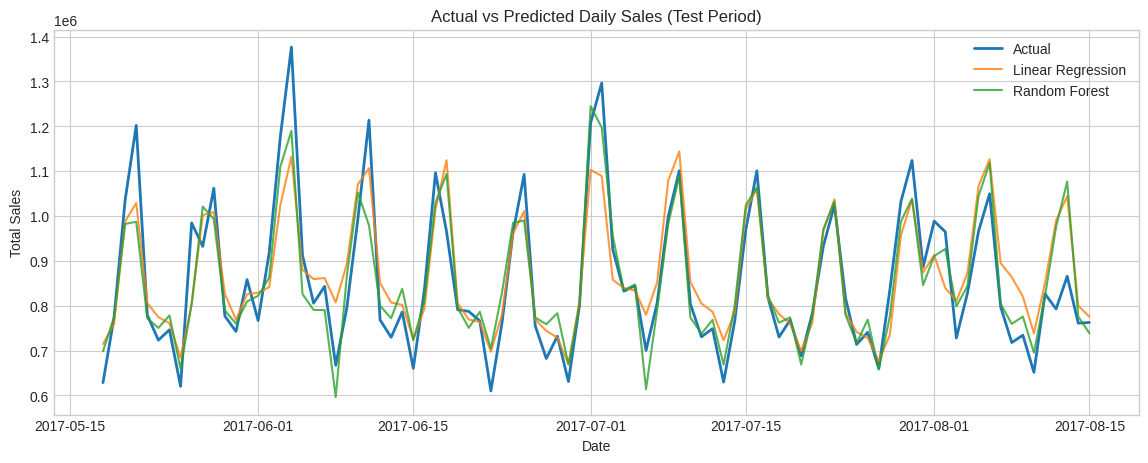

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(test["date"], y_test, label="Actual", linewidth=2)
plt.plot(test["date"], pred_lr, label="Linear Regression", alpha=0.8)
plt.plot(test["date"], pred_rf, label="Random Forest", alpha=0.8)
plt.title("Actual vs Predicted Daily Sales (Test Period)")
plt.xlabel("Date"); plt.ylabel("Total Sales")
plt.legend(); plt.show()

In [ ]:
best_model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
best_model.fit(daily[features], daily[target])     # use LinearRegression() here if it scored better

history = daily.set_index("date")["sales"].copy()
first_date, first_idx = daily["date"].iloc[0], daily["time_index"].iloc[0]

# Holidays are unknown in the future, so reuse the month-day pairs of past national holidays
holiday_md = set(zip(daily.loc[daily.is_holiday == 1, "date"].dt.month,
                     daily.loc[daily.is_holiday == 1, "date"].dt.day))

def build_row(d, hist):
    month_end = d.is_month_end
    row = {
        "year": d.year, "month": d.month, "quarter": d.quarter, "day": d.day,
        "day_of_week": d.dayofweek, "week_of_year": d.isocalendar().week,
        "day_of_year": d.dayofyear, "is_weekend": int(d.dayofweek >= 5),
        "is_month_start": int(d.is_month_start), "is_month_end": int(month_end),
        "is_payday": int(d.day == 15 or month_end),
        "is_holiday": int((d.month, d.day) in holiday_md),
        "time_index": (d - first_date).days + first_idx,
        "month_sin": np.sin(2*np.pi*d.month/12), "month_cos": np.cos(2*np.pi*d.month/12),
        "dow_sin": np.sin(2*np.pi*d.dayofweek/7), "dow_cos": np.cos(2*np.pi*d.dayofweek/7),
        "sales_lag_7":  hist[d - pd.Timedelta(days=7)],
        "sales_lag_14": hist[d - pd.Timedelta(days=14)],
        "sales_lag_28": hist[d - pd.Timedelta(days=28)],
        "sales_roll_mean_7":  hist[d - pd.Timedelta(days=7):  d - pd.Timedelta(days=1)].mean(),
        "sales_roll_mean_28": hist[d - pd.Timedelta(days=28): d - pd.Timedelta(days=1)].mean(),
    }
    return pd.DataFrame([row])[features]

horizon = 90
future_dates = pd.date_range(daily["date"].max() + pd.Timedelta(days=1), periods=horizon)
future_preds = []

for d in future_dates:
    p = best_model.predict(build_row(d, history))[0]
    history.loc[d] = p                       # feed the prediction back in
    future_preds.append(p)

forecast = pd.DataFrame({"date": future_dates, "forecast_sales": future_preds})
forecast.head()

,date,forecast_sales
0,2017-08-16,761760.034381
1,2017-08-17,676440.839776
2,2017-08-18,785267.439781
3,2017-08-19,873904.368258
4,2017-08-20,893921.603404


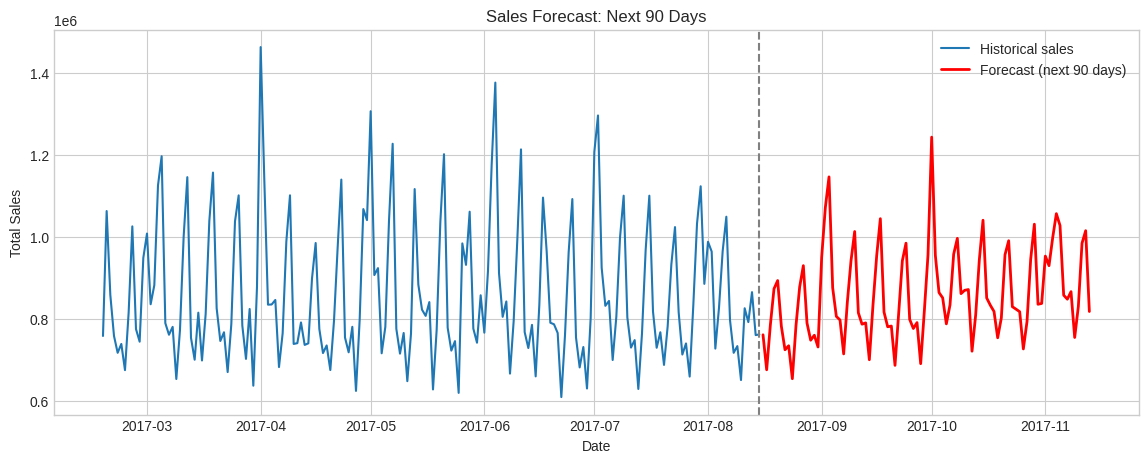

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(daily["date"].iloc[-180:], daily["sales"].iloc[-180:], label="Historical sales")
plt.plot(forecast["date"], forecast["forecast_sales"], label="Forecast (next 90 days)",color="red", linewidth=2)
plt.axvline(daily["date"].max(), color="gray", linestyle="--")
plt.title("Sales Forecast: Next 90 Days")
plt.xlabel("Date");
plt.ylabel("Total Sales")
plt.legend();
plt.show()

## **Monthly sales: history plus forecast**

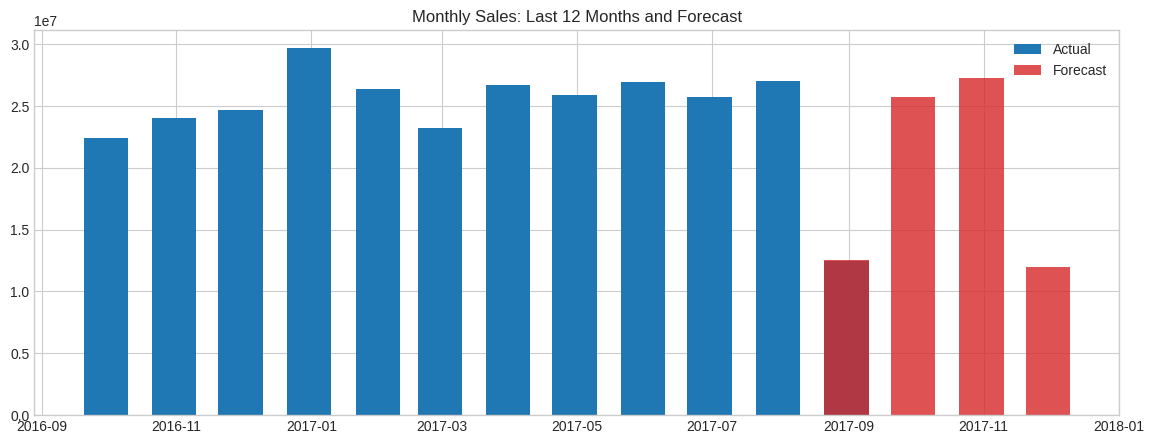

In [ ]:
hist_m = daily.set_index("date")["sales"].resample("M").sum()
fc_m   = forecast.set_index("date")["forecast_sales"].resample("M").sum()

plt.figure(figsize=(14, 5))
plt.bar(hist_m.index[-12:], hist_m.iloc[-12:], width=20, label="Actual", color="tab:blue")
plt.bar(fc_m.index, fc_m, width=20, label="Forecast", color="tab:red", alpha=0.8)
plt.title("Monthly Sales: Last 12 Months and Forecast")
plt.legend(); plt.show()

## **Smoothed trend**

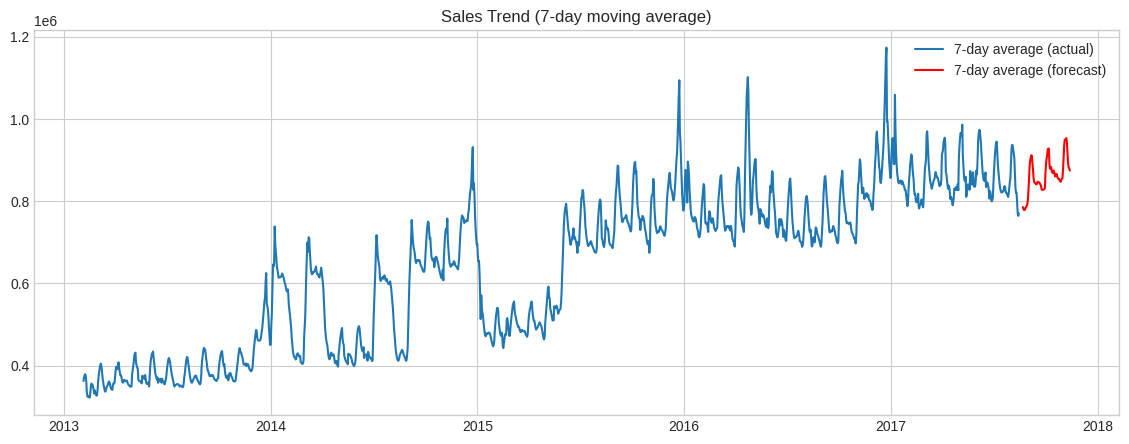

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(daily["date"], daily["sales"].rolling(7).mean(), label="7-day average (actual)")
plt.plot(forecast["date"], forecast["forecast_sales"].rolling(7).mean(), color="red", label="7-day average (forecast)")
plt.title("Sales Trend (7-day moving average)")
plt.legend(); plt.show()

## **Actual vs predicted scatter**

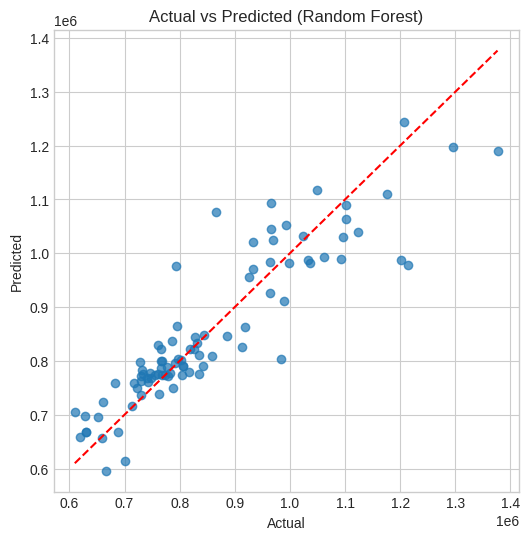

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_rf, alpha=0.7)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, color="red", linestyle="--")      # perfect prediction line
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

## **Business insight charts**

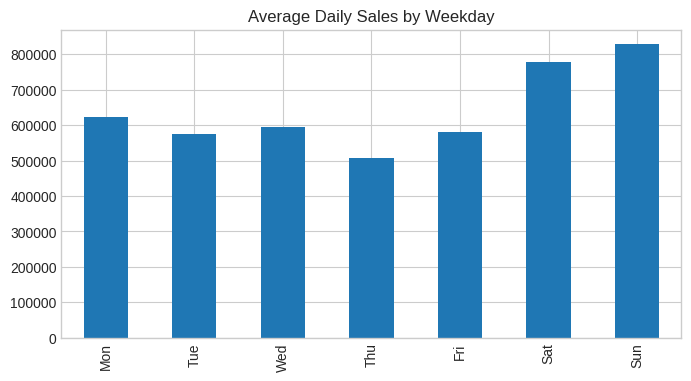

In [ ]:
# Average sales by weekday
dow = daily.groupby("day_of_week")["sales"].mean()
dow.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow.plot(kind="bar", figsize=(8,4), title="Average Daily Sales by Weekday", color="tab:blue")
plt.show()

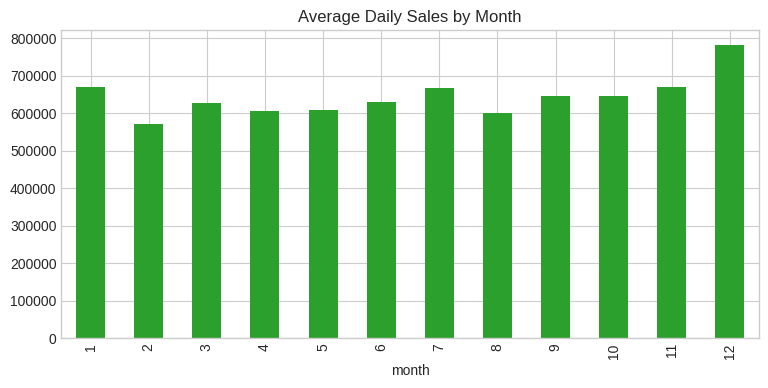

In [ ]:
# Average sales by month
daily.groupby("month")["sales"].mean().plot(kind="bar", figsize=(9,4),
        title="Average Daily Sales by Month", color="tab:green")
plt.show()

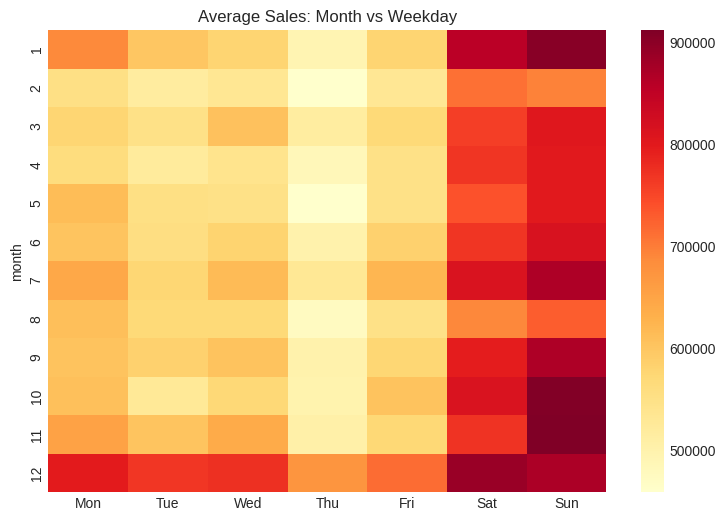

In [ ]:
# Heatmap: month vs weekday
pivot = daily.pivot_table(values="sales", index="month", columns="day_of_week", aggfunc="mean")
pivot.columns = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
plt.figure(figsize=(9,6))
sns.heatmap(pivot, cmap="YlOrRd", annot=False)
plt.title("Average Sales: Month vs Weekday");
plt.show()

## **Using your merged data**

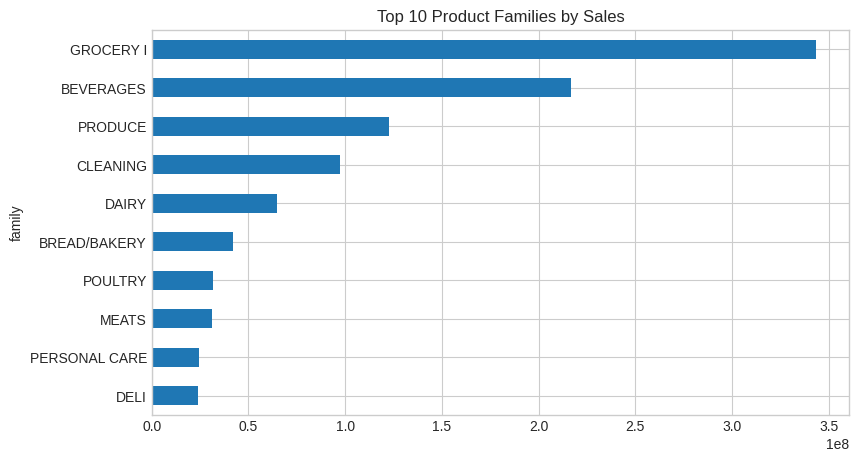

In [ ]:
# Top product families
store_data.groupby("family")["sales"].sum().sort_values().tail(10).plot(
    kind="barh", figsize=(9,5), title="Top 10 Product Families by Sales")
plt.show()

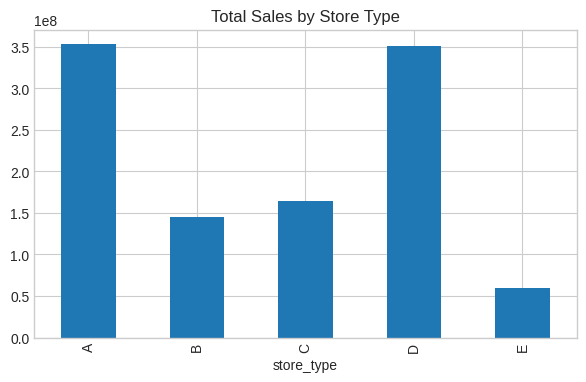

In [ ]:
# Sales by store type
store_data.groupby("store_type")["sales"].sum().plot(
    kind="bar", figsize=(7,4), title="Total Sales by Store Type")
plt.show()

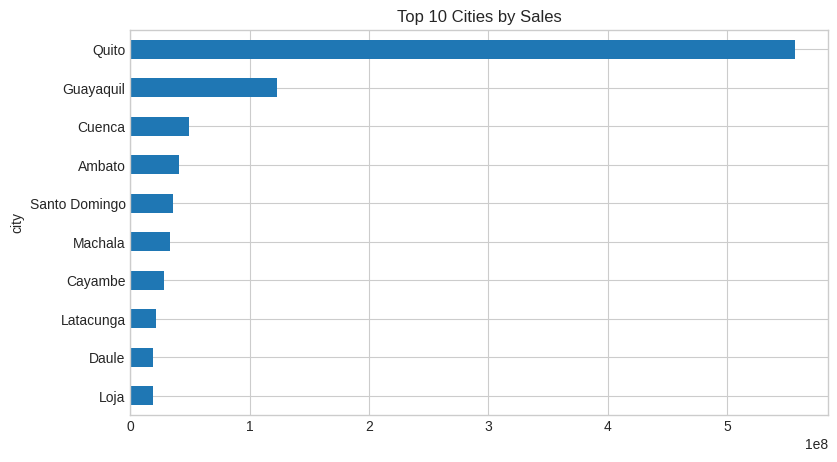

In [ ]:
# Top cities
store_data.groupby("city")["sales"].sum().sort_values().tail(10).plot(
    kind="barh", figsize=(9,5), title="Top 10 Cities by Sales")
plt.show()

# **Model evaluation and error analysis**

In [ ]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE": MAE(y_true, y_pred),
        "RMSE": np.sqrt(MSE(y_true, y_pred)),
        "MAPE %": MAPE(y_true, y_pred) * 100,
        "R²": R2(y_true, y_pred),
    }

eval_table = pd.DataFrame([
    evaluate("Linear Regression", y_test, pred_lr),
    evaluate("Random Forest", y_test, pred_rf),
]).round(2)

print(eval_table)

# Compare against a naive baseline: "same weekday last week"
naive = test["sales_lag_7"]
print(evaluate("Naive (lag 7)", y_test, naive))
#print(evaluate("Naive (lag 7)", y_test, naive)*100)

               Model       MAE      RMSE  MAPE %    R²
0  Linear Regression  63475.62  81707.84    7.30  0.75
1      Random Forest  51226.75  70960.19    5.81  0.81
{'Model': 'Naive (lag 7)', 'MAE': 93934.85540425777, 'RMSE': np.float64(122634.69682848196), 'MAPE %': 10.46534748072072, 'R²': 0.4415960693295291}


In [ ]:
err = test[["date", "sales"]].copy()
err["predicted"]  = pred_rf
err["error"]      = err["sales"] - err["predicted"]        # + = under-predicted
err["abs_error"]  = err["error"].abs()
err["pct_error"]  = err["abs_error"] / err["sales"] * 100
err["day_name"]   = err["date"].dt.day_name()
err["is_holiday"] = test["is_holiday"].values
err["is_payday"]  = test["is_payday"].values

# 1. Worst 10 days
print(err.sort_values("abs_error", ascending=False).head(10).round(0))

# 2. Error by weekday
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
print(err.groupby("day_name")[["abs_error", "pct_error"]].mean().reindex(order).round(1))

# 3. Holiday and payday vs normal days
print(err.groupby("is_holiday")[["abs_error", "pct_error"]].mean().round(1))
print(err.groupby("is_payday")[["abs_error", "pct_error"]].mean().round(1))

# 4. Bias
print("Average error (actual - predicted):", round(err["error"].mean()))
print("Days within 10% error:", f"{(err['pct_error'] <= 10).mean()*100:.0f}%")

           date      sales  predicted     error  abs_error  pct_error  \
1594 2017-06-11  1213674.0   979074.0  234600.0   234600.0       19.0   
1573 2017-05-21  1201939.0   986992.0  214947.0   214947.0       18.0   
1657 2017-08-13   865640.0  1076583.0 -210943.0   210943.0       24.0   
1587 2017-06-04  1376512.0  1189869.0  186643.0   186643.0       14.0   
1656 2017-08-12   792631.0   976074.0 -183443.0   183443.0       23.0   
1578 2017-05-26   984511.0   804100.0  180412.0   180412.0       18.0   
1601 2017-06-18   965144.0  1093429.0 -128285.0   128285.0       13.0   
1608 2017-06-25  1092611.0   990013.0  102597.0   102597.0        9.0   
1615 2017-07-02  1296379.0  1197364.0   99015.0    99015.0        8.0   
1605 2017-06-22   609869.0   704169.0  -94301.0    94301.0       15.0   

      day_name  is_holiday  is_payday  
1594    Sunday           0          0  
1573    Sunday           0          0  
1657    Sunday           0          0  
1587    Sunday           0          

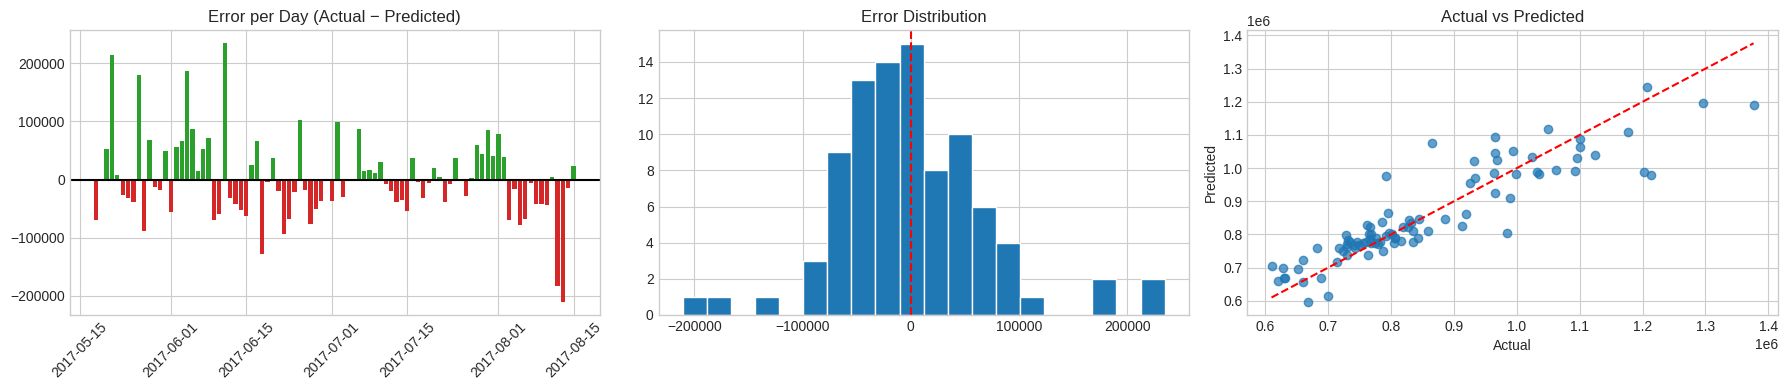

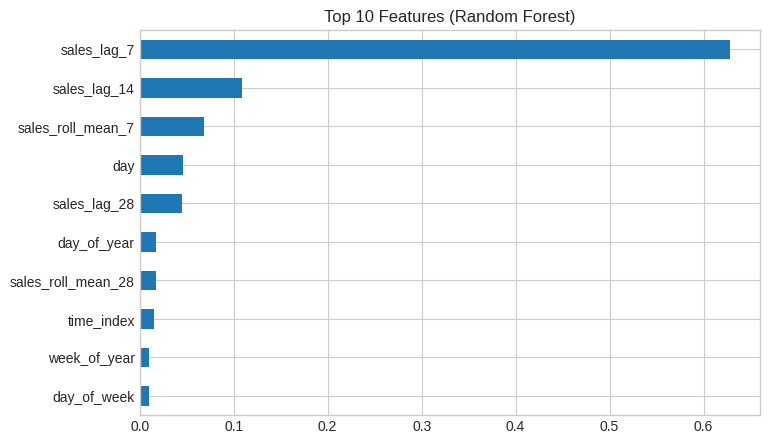

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

# Error over time
ax[0].bar(err["date"], err["error"], color=np.where(err["error"] > 0, "tab:green", "tab:red"))
ax[0].axhline(0, color="black"); ax[0].set_title("Error per Day (Actual − Predicted)")
ax[0].tick_params(axis="x", rotation=45)

# Error distribution
ax[1].hist(err["error"], bins=20, color="tab:blue", edgecolor="white")
ax[1].axvline(0, color="red", linestyle="--"); ax[1].set_title("Error Distribution")

# Actual vs predicted
ax[2].scatter(y_test, pred_rf, alpha=0.7)
lim = [y_test.min(), y_test.max()]
ax[2].plot(lim, lim, color="red", linestyle="--")
ax[2].set_title("Actual vs Predicted"); ax[2].set_xlabel("Actual"); ax[2].set_ylabel("Predicted")

plt.tight_layout(); plt.show()

# Feature importance
pd.Series(rf.feature_importances_, index=features).sort_values().tail(10).plot(
    kind="barh", figsize=(8, 5), title="Top 10 Features (Random Forest)")
plt.show()

# **Business-friendly visual forecast output**

In [ ]:
from matplotlib.ticker import FuncFormatter
m_fmt = FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")   # 800000 -> 0.8M

# Uncertainty range from the test-period error
resid_std = np.std(y_test.values - pred_rf)
fc = forecast.copy()
fc["upper"] = fc["forecast_sales"] + 1.96 * resid_std
fc["lower"] = (fc["forecast_sales"] - 1.96 * resid_std).clip(lower=0)

# Same period last year (364 days back keeps the weekdays aligned)
hist = daily.set_index("date")["sales"]
fc["last_year"] = hist.reindex(fc["date"] - pd.Timedelta(days=364)).values

# Key numbers
total_fc   = fc["forecast_sales"].sum()
total_ly   = fc["last_year"].sum()
growth     = (total_fc / total_ly - 1) * 100
peak_row   = fc.loc[fc["forecast_sales"].idxmax()]
low_row    = fc.loc[fc["forecast_sales"].idxmin()]

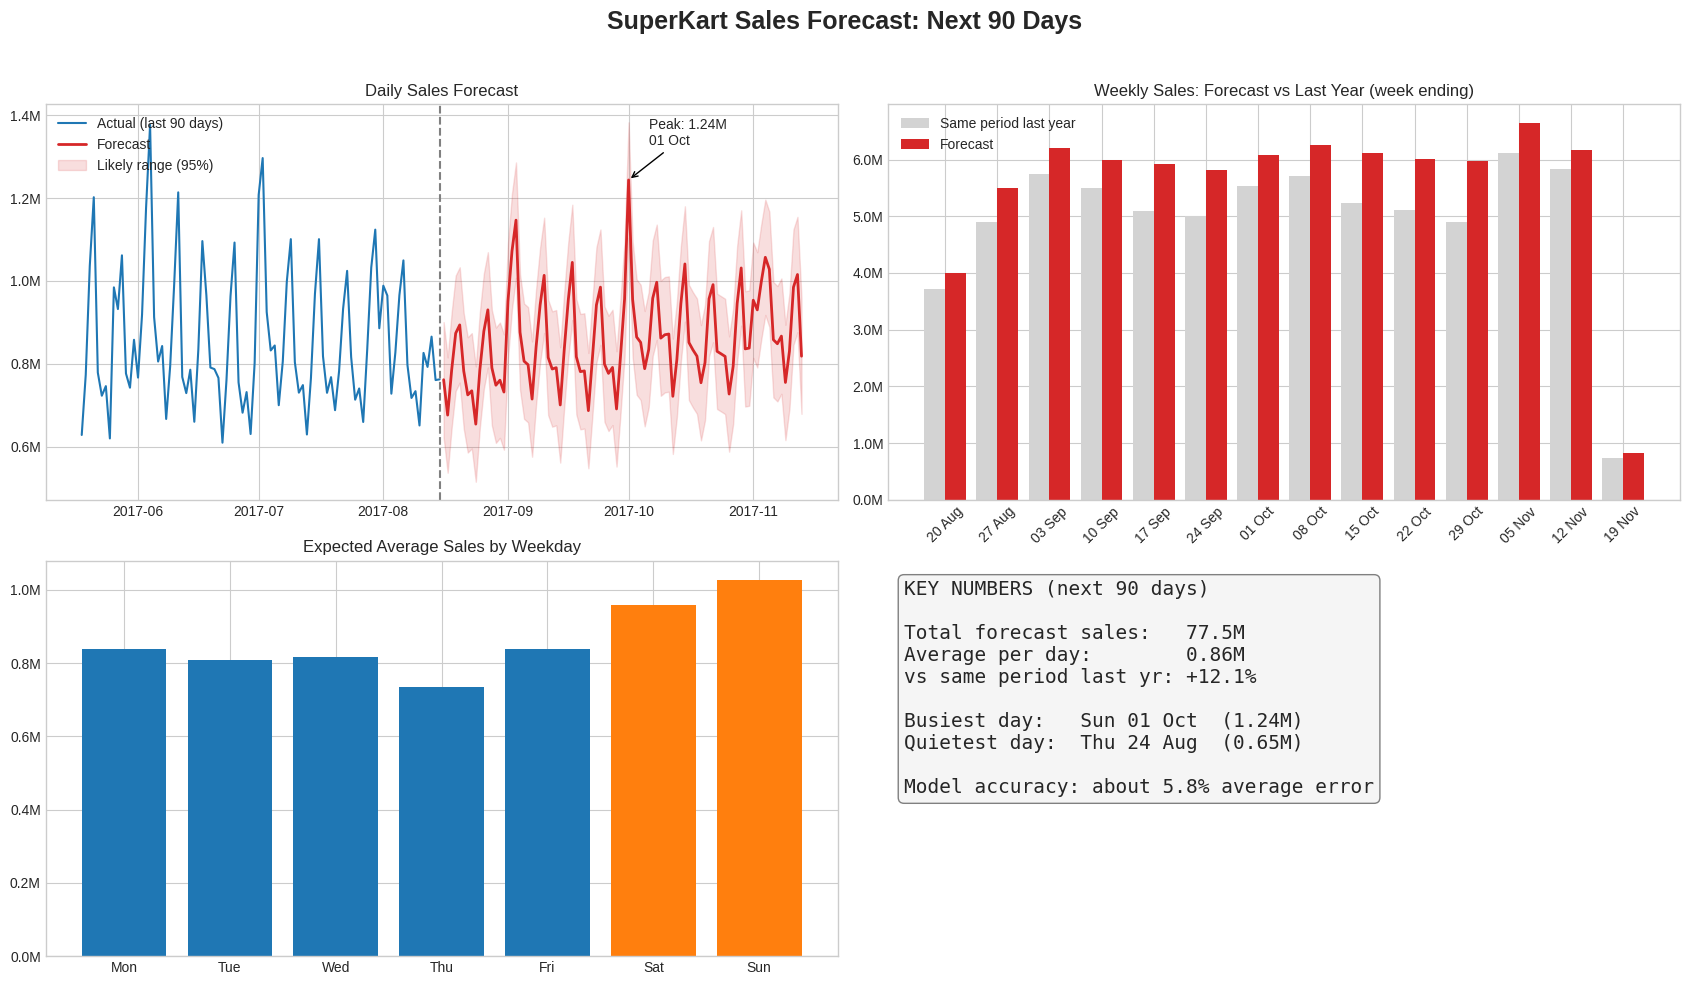

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(17, 10))
fig.suptitle("SuperKart Sales Forecast: Next 90 Days", fontsize=18, fontweight="bold")

# 1. Forecast with range
a = ax[0, 0]
a.plot(daily["date"].iloc[-90:], daily["sales"].iloc[-90:], color="tab:blue", label="Actual (last 90 days)")
a.plot(fc["date"], fc["forecast_sales"], color="tab:red", linewidth=2, label="Forecast")
a.fill_between(fc["date"], fc["lower"], fc["upper"], color="tab:red", alpha=0.15, label="Likely range (95%)")
a.axvline(daily["date"].max(), color="gray", linestyle="--")
a.annotate(f"Peak: {peak_row['forecast_sales']/1e6:.2f}M\n{peak_row['date']:%d %b}",
           xy=(peak_row["date"], peak_row["forecast_sales"]),
           xytext=(15, 25), textcoords="offset points", arrowprops=dict(arrowstyle="->"))
a.yaxis.set_major_formatter(m_fmt)
a.set_title("Daily Sales Forecast"); a.legend(loc="upper left")

# 2. Weekly forecast vs same period last year
w = fc.set_index("date")[["forecast_sales", "last_year"]].resample("W").sum()
x = np.arange(len(w)); bw = 0.4
b = ax[0, 1]
b.bar(x - bw/2, w["last_year"], bw, label="Same period last year", color="lightgray")
b.bar(x + bw/2, w["forecast_sales"], bw, label="Forecast", color="tab:red")
b.set_xticks(x); b.set_xticklabels([d.strftime("%d %b") for d in w.index], rotation=45)
b.yaxis.set_major_formatter(m_fmt)
b.set_title("Weekly Sales: Forecast vs Last Year (week ending)"); b.legend()

# 3. Average forecast by weekday
d = fc.assign(dow=fc["date"].dt.dayofweek).groupby("dow")["forecast_sales"].mean()
d.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
c = ax[1, 0]
c.bar(d.index, d.values, color=["tab:blue"]*5 + ["tab:orange"]*2)
c.yaxis.set_major_formatter(m_fmt)
c.set_title("Expected Average Sales by Weekday")

# 4. Key numbers panel
k = ax[1, 1]; k.axis("off")
summary = (
    f"KEY NUMBERS (next 90 days)\n\n"
    f"Total forecast sales:   {total_fc/1e6:,.1f}M\n"
    f"Average per day:        {total_fc/90/1e6:.2f}M\n"
    f"vs same period last yr: {growth:+.1f}%\n\n"
    f"Busiest day:   {peak_row['date']:%a %d %b}  ({peak_row['forecast_sales']/1e6:.2f}M)\n"
    f"Quietest day:  {low_row['date']:%a %d %b}  ({low_row['forecast_sales']/1e6:.2f}M)\n\n"
    f"Model accuracy: about {MAPE(y_test, pred_rf)*100:.1f}% average error"
)
k.text(0.02, 0.95, summary, va="top", fontsize=14, family="monospace",
       bbox=dict(boxstyle="round", facecolor="#f5f5f5", edgecolor="gray"))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("sales_forecast_dashboard.png", dpi=200, bbox_inches="tight")
plt.show()

The last-year comparison is approximate. Last year had different holidays and conditions, and the first and last weeks are partial, so say "roughly" when you present the growth figure.

The range comes from the test period's errors. The 90-day forecast feeds on its own predictions, so the true uncertainty is a bit wider. This is another point for your limitations section.